# Idea : Maybe we can solve our convergence problems by having a different approach to the contrastive learning phase
1) Patient wise representations per modality (distinctively)
2) Learn the final representation by using self attention on embeddings paired with presence tokens (i.e learned tokens to represent the presence/absence of a modality)

## Why ?
1) Allows modality specific convergence while learning patient-wise embeddings. Modulo that we achieve convergence (i.e, unique representations per patients for each modality), the contatenated embedding will therefore also be unique which thus allows a unique representation of each patient in the dataset across modalities.
2) Because we would like to integrate across the different modalities (i.e. biological scales) we would like to slightly update the original representation concatenated from all 6 modalities with cross modality patterns => Self-Attention on the concatenated embeddings. However because having missing modalities is important to take into account, learning small embeddings that encode the presence/absence of each modality could help enrich the final representation.

## How ?
1) Compute 6 contrastive losses per batch, backpropagate gradient for each of them individually => 6 loss computations, 6 optimizers, 6 schedulers, 6 loss.backward()
2) Add an Attention block that takes as input the concatenated embedding and output the cross-modality enriched representation
   + Have another Attention block that takes the missing modalities vector ([1,0,0,1,1,1]) as input and output a representation of the modality statuses for the patient (a dense layer might be necessary prior to that to encode it instead of simply having binary signal as input to the attention layer)
   + Have a final attention mechanism that queries the missing modality representation with respect to the cross-modality representation in order to integrate the status of each modality into the final embedding of the patient.
     
Note: The 2) point is done by the clinical linkage phase (i.e. predictive learning phase). Thus we need:
- The MultiModalEncoder
- The PredictiveHead = (Attention blocks + MLP per task)

In [1]:
import sys
import os

project_path = "/home/sagemaker-user/gbm_hackathon"
if project_path not in sys.path:
    sys.path.append(project_path)
    print(sys.path)

['/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python310.zip', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/lib-dynload', '', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages', '/home/sagemaker-user/gbm_hackathon']


In [2]:
%load_ext autoreload
%autoreload 2

from gbmhackathon.training.predictive import *
from gbmhackathon.models.mme import GBMNet, ClinicalLinkageModule
from gbmhackathon.utils.loss_functions import InfoNCELoss, RegularizedInfoNCELoss, SmoothingFunction, RankMe, make_patient_map
from gbmhackathon.utils.module_functions import instantiate
from gbmhackathon.utils.analysis import *
from gbmhackathon.viz.viz_experiment import *
from gbmhackathon.s3_loader import load_s3

import os
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# To investigate gradients
from torchviz import make_dot

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam

In [3]:
torch.set_num_threads(4)
torch.get_num_threads()

6

In [4]:
device = "cpu" #"cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)

In [5]:
name_emb_dict = {"hne":"embeddings_HnE_OptimusH0.pkl",
#"spatial":"2025-03-23_18-32_spatial_emb_V1.pkl",
"clinical":"2025-03-30_14-23_clinical_emb_V1.pkl",
"wes":"2025-04-05_13-40_wes_emb_V1.pkl",
"bulk":"2025-05-03_10-15_bulk_emb_V1.pkl",
"scRNA":"2025-05-04_02-35_scRNA_emb_V1.pkl"}
pkl_storage_folder = "embedding_V1"

In [6]:
dataset = PredictiveLearningDataset(name_emb_dict, pkl_storage_folder, device=device, dropout=1.0)
print(f"Dataset size: {len(dataset)}")
BATCH_SIZE = 582
dataloader = DataLoader(dataset, BATCH_SIZE, shuffle=True, collate_fn=collate_predictive, generator=torch.Generator(device=dataset.device))

cas 2 : device reconnu : cpu 
Using device: cpu
By keeping 100.00% of dropout augmented samples we went from:
468 dropout samples (80.41% dropout in dataset) -- to --> 468 dropout samples (80.41% dropout in dataset)
Dataset size: 582


In [7]:
# Batch of all true samples (no dropout augmented samples)
batch_all = [dataset.__getitem__(idx) for idx in dataset.ind2patient if 'd' not in dataset.ind2patient[idx]]
batch_all = collate_predictive(batch_all)

In [8]:
raw_emb = next(iter(dataloader))[2]
inpute_size_dict = {}
for mod in raw_emb.keys():
    print(mod, raw_emb[mod].size())
    inpute_size_dict[mod] = raw_emb[mod].size(1)

hne torch.Size([582, 1536])
clinical torch.Size([582, 12])
wes torch.Size([582, 1790])
bulk torch.Size([582, 3072])
scRNA torch.Size([582, 3072])


In [9]:
patient_map = make_patient_map(dataset)

In [10]:
def adapt_base_config(base_cfg, input_size):
    base_copy = deepcopy(base_cfg)
    base_copy["layers"] = [input_size] + base_copy["layers"]
    return base_copy

In [11]:
out = 32
norm_fn = nn.BatchNorm1d
base_cfg = {"layers": [512,128,out],
        "dropout": 0.3,
        "act_fn":nn.GELU,
        "norm_layer":norm_fn,
        "device":device}

hne_cfg = {"layers": [512,128,out],
        "dropout": 0.3,
        "act_fn":nn.GELU,
        "norm_layer":norm_fn,
        "device":device}

clinical_cfg = {"layers": [256,128,out],
        "dropout": 0.3,
        "act_fn":nn.GELU,
        "norm_layer":norm_fn,
        "device":device}

wes_cfg = {"layers": [512,128,out],
        "dropout": 0.3,
        "act_fn":nn.GELU,
        "norm_layer":norm_fn,
        "device":device}

rna_cfg = {"layers": [1024,256,out],
        "dropout": 0.3,
        "act_fn":nn.GELU,
        "norm_layer":norm_fn,
        "device":device}


hne_cfg = adapt_base_config(hne_cfg, inpute_size_dict["hne"])
#spatial_cfg = adapt_base_config(small_capacity_cfg, inpute_size_dict["spatial"])
clinical_cfg = adapt_base_config(clinical_cfg, inpute_size_dict["clinical"])
wes_cfg = adapt_base_config(wes_cfg, inpute_size_dict["wes"])
bulk_cfg = adapt_base_config(rna_cfg, inpute_size_dict["bulk"])
sc_cfg = adapt_base_config(rna_cfg, inpute_size_dict["scRNA"])

In [12]:
mme_bulk_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": bulk_cfg}

mme_hne_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": hne_cfg}

mme_sc_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": sc_cfg}

mme_wes_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": wes_cfg}

mme_clinical_cfg = {"net_type": "mlp",
                "device": device,
                "net_config": clinical_cfg}

In [13]:
mme_cfg = {"hne_cfg":mme_hne_cfg, 
           "clinical_cfg":mme_clinical_cfg, 
           "wes_cfg":mme_wes_cfg, 
           #"spatial_cfg":mme_spatial_cfg,
           "bulk_cfg":mme_bulk_cfg,
          "sc_cfg":mme_sc_cfg}

In [14]:
base_head_cfg = {"layers": [out*len(mme_cfg),1024,512,5],
        "dropout": 0.3,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":[nn.ReLU, nn.ReLU, None],
        "norm_layer":norm_fn,
        "device":device}
head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": base_head_cfg}

In [15]:
gbmnet_cfg = {"head_cfg": head_cfg,
        "load_mme": False,
        "freeze_mme": False,
        "mme_path": None,
        "mme_cfg": mme_cfg}

In [16]:
gbmnet = instantiate(gbmnet_cfg, GBMNet)

EPOCHS_I = 55
base_lr_I = 1e-3
eta_min_coef = 0.1
scheduler_I_class = torch.optim.lr_scheduler.CosineAnnealingLR
scheduler_I_cfg = {"T_max":EPOCHS_I,
                  "eta_min":"dynamic"}

contrastive_loss_cfg = {"modalities":list(name_emb_dict.keys()),
                        "patient_map":patient_map,
                        "temperature":0.05,
                        "similarity":'nt-xent',
                        "use_all_positives":False,
                        "alpha":0,
                        "bound":-50,
                        "slope":0.1,
                        "rate":-5,
                        "warn":False,
                       "smoothing_func":False}

{'net_type': 'mlp', 'device': 'cpu', 'net_config': {'layers': [1536, 512, 128, 32], 'dropout': 0.3, 'act_fn': <class 'torch.nn.modules.activation.GELU'>, 'norm_layer': <class 'torch.nn.modules.batchnorm.BatchNorm1d'>, 'device': 'cpu'}}
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found


/home/sagemaker-user/gbm_hackathon/gbmhackathon/utils/module_functions.py:25: ParameterNotFoundWarning: Parameter device not found in init arguments: ['self', 'layers', 'dropout', 'act_fn', 'norm_layer', 'enable_residuals'].
  warnings.warn(


EPOCH 1 AVERAGE TOTAL LOSS ACROSS MODALITIES: 8.0390


/home/sagemaker-user/gbm_hackathon/gbmhackathon/viz/viz_experiment.py:151: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


EPOCH 2 AVERAGE TOTAL LOSS ACROSS MODALITIES: 7.6440


/home/sagemaker-user/gbm_hackathon/gbmhackathon/viz/viz_experiment.py:151: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


EPOCH 3 AVERAGE TOTAL LOSS ACROSS MODALITIES: 7.0592


...

/home/sagemaker-user/gbm_hackathon/gbmhackathon/viz/viz_experiment.py:151: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


EPOCH 54 AVERAGE TOTAL LOSS ACROSS MODALITIES: 4.2234


/home/sagemaker-user/gbm_hackathon/gbmhackathon/viz/viz_experiment.py:151: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


EPOCH 55 AVERAGE TOTAL LOSS ACROSS MODALITIES: 4.2130


/home/sagemaker-user/gbm_hackathon/gbmhackathon/viz/viz_experiment.py:151: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


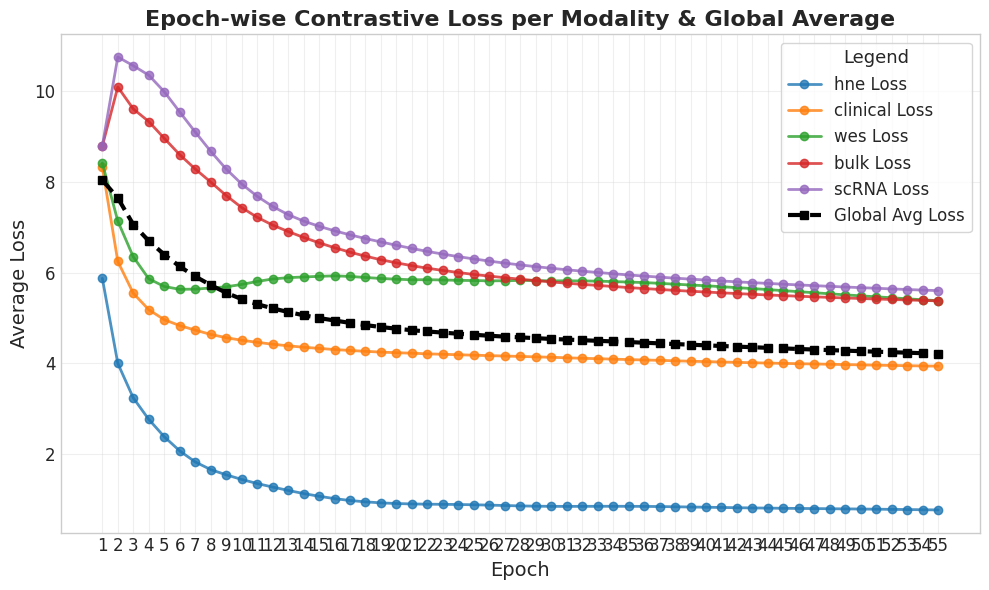

In [17]:
# Initialize metric collectors
pos_aligns_I, neg_aligns_I, distance_aligns_I = [], [], []
embedding_metrics = []

# Optimization for Phase I
optimizer_I = Adam(gbmnet.mme.parameters(), lr=base_lr_I)
scheduler_I_cfg["optimizer"] = optimizer_I
if "eta_min" in scheduler_I_cfg.keys():
    if scheduler_I_cfg["eta_min"] == "dynamic":
        scheduler_I_cfg["eta_min"] = eta_min_coef * base_lr_I
scheduler_I = instantiate(scheduler_I_cfg, scheduler_I_class)

assert contrastive_loss_cfg is not None, "You must provide a config for the contrastive loss"

contrastive_loss_fn = instantiate(contrastive_loss_cfg, RegularizedInfoNCELoss)

# Phase I training loop
EPOCHS_I_LOSSES = []
modalities = next(iter(dataloader))[2].keys()

# A contrastive loss module per modality
modality_contrastive_loss_fn = {}
for modality in modalities:
    contrastive_loss_cfg_mod = contrastive_loss_cfg.copy()
    contrastive_loss_cfg_mod['modalities'] = [modality]
    modality_contrastive_loss_fn[modality] = instantiate(contrastive_loss_cfg_mod, RegularizedInfoNCELoss)

# An optimizer per modality
modality_optimizers = {modality:Adam(gbmnet.mme.modality_net_map[modality].parameters(), lr=base_lr_I) for modality in modalities}

# A scheduler per modality
modality_schedulers = {}
for modality in modalities:
    # Same schedule for all modalities for now, but it can be configurable
    scheduler_cfg = scheduler_I_cfg.copy()
    scheduler_cfg["optimizer"] = modality_optimizers[modality]
    if "eta_min" in scheduler_I_cfg.keys():
        if scheduler_cfg["eta_min"] == "dynamic":
            scheduler_cfg["eta_min"] = eta_min_coef * base_lr_I
    modality_schedulers[modality] = instantiate(scheduler_cfg, scheduler_I_class)

# Logging of modality losses at each batch
modality_batch_loss = {modality:[] for modality in modalities}

# Logging of modality losses per epoch
modality_avg_loss = {modality:[] for modality in modalities}

# Save embedding plots
emb_frame_dirs = ['emb_mme', 'emb_by_mod', 'emb_by_patient']
            
for d in emb_frame_dirs:
    os.makedirs(d, exist_ok=True)
        
for epoch in range(1, EPOCHS_I+1):
    epoch_loss = []
    
    for idx, batch in enumerate(dataloader):
        # Get batch
        patient_ids, modalities, X_dict, avail_mods, batch_targets, targets_names = batch
        # print(batch_targets.size())
        # Forward pass
        contrastive_outputs, _ = gbmnet(X_dict)
        # print(predictive_outputs.size())
        contrastive_loss_batch = (contrastive_outputs, patient_ids, avail_mods)

        # Loss computation 
        for modality in contrastive_outputs.keys():
            contrastive_loss_batch = ({modality:contrastive_outputs[modality]}, patient_ids, avail_mods)
            modality_loss = modality_contrastive_loss_fn[modality](contrastive_loss_batch)
            modality_loss.backward()
            modality_optimizers[modality].step()
            modality_schedulers[modality].step()
            modality_batch_loss[modality].append(modality_loss.item())

    for modality in modality_batch_loss.keys():
        modality_avg_loss[modality].append(np.mean(modality_batch_loss[modality]))
        # print(f"Epoch {epoch} {modality} total loss: {modality_avg_loss[modality][-1]:.4f}".upper())

    total_cross_modality_avg_loss = np.mean([epoch_losses[-1] for epoch_losses in modality_avg_loss.values()])
    print(f"Epoch {epoch} average total loss across modalities: {total_cross_modality_avg_loss:.4f}".upper())

    EPOCHS_I_LOSSES.append(total_cross_modality_avg_loss)
    
    # capture embeddings figures instead of immediate plotting
    figs = see_emb(batch_all, gbmnet, reducer='tsne')
    for i, fig in enumerate(figs):
        path = os.path.join(emb_frame_dirs[i], f'epoch_{epoch:03d}.png')
        fig.savefig(path, dpi=150, bbox_inches='tight')
        plt.close(fig)

    # with torch.no_grad():
    #     # Analyser les embeddings tous les N epochs
    #     if epoch % 5 == 0 or epoch == EPOCHS_I - 1:
    #         save_dir = f"embedding_analysis/epoch_{epoch}"
    #         os.makedirs(save_dir, exist_ok=True)
    #         modality_keys = gbmnet.mme.modality_net_map.keys()
    #         metrics = analyze_embeddings_after_epoch(
    #             model=gbmnet,
    #             dataloader=dataloader,
    #             modality_keys=modality_keys,
    #             patient_map=patient_map,
    #             device=gbmnet.mme.modality_net_map[list(gbmnet.mme.modality_net_map.keys())[0]].device,
    #             num_batches=-1,  # Analyser 2 batchs
    #             visualize=True,
    #             save_dir=save_dir
    #         )
            
    #         embedding_metrics.append({
    #             'epoch': epoch,
    #             'metrics': metrics
    #         })
            
    #         # Visualiser l'évolution des métriques
    #         if len(embedding_metrics) > 1:
    #             visualize_metrics_evolution(embedding_metrics, save_dir=save_dir)
# Prepare data
epochs = list(range(1, len(EPOCHS_I_LOSSES) + 1))
global_avg = EPOCHS_I_LOSSES

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')  # clean, modern grid

fig, ax = plt.subplots(figsize=(10, 6))

# Plot per-modality curves
for modality, losses in modality_avg_loss.items():
    ax.plot(epochs, losses, marker='o', linewidth=2, alpha=0.8, label=f'{modality} Loss')

# Plot global cross-modality average
ax.plot(epochs, global_avg,
        marker='s', linewidth=3, linestyle='--',
        color='black', label='Global Avg Loss')

# Aesthetic tweaks
ax.set_title('Epoch-wise Contrastive Loss per Modality & Global Average', fontsize=16, weight='bold')
ax.set_xlabel('Epoch', fontsize=14)
ax.set_ylabel('Average Loss', fontsize=14)
ax.set_xticks(epochs)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(title='Legend', fontsize=12, title_fontsize=13, loc='upper right', frameon=True)
ax.grid(True, which='major', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
make_matplotlib_gif('emb_mme', 'emb_mme_animation.gif', fps=4, max_frames=EPOCHS_I)
make_matplotlib_gif('emb_by_mod', 'emb_by_modality_animation.gif', fps=4, max_frames=EPOCHS_I)
make_matplotlib_gif('emb_by_patient', 'emb_by_patient_animation.gif', fps=4, max_frames=EPOCHS_I)

Saved animation to emb_mme_animation.gif
Saved animation to emb_by_modality_animation.gif
Saved animation to emb_by_patient_animation.gif


In [19]:
reg_head_cfg = {"layers": [out*len(mme_cfg),512,256,1],
        "dropout": 0.3,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":[nn.GELU, nn.GELU, None],
        "norm_layer":norm_fn,
        "device":device}
clf_head_cfg = {"layers": [out*len(mme_cfg),512,256,2],
        "dropout": 0.3,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":[nn.GELU, nn.GELU, None],
        "norm_layer":norm_fn,
        "device":device}

In [20]:
os_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
pfs_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
diameter_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
recurrency_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": clf_head_cfg}

In [21]:
# ATTENTION !!!! MUST BE THIS EXACT ORDER FOR PREDICTIVE TASKS: 
# ['os_years', 'pfs_years', 'largest_diameter_of_the_primary_tumour_mm_duplicated_0', 'recurrent_sample']
predictive_cfg = {"heads_configs":{"os": os_head_cfg,
                  "pfs": pfs_head_cfg,
                  "diameter": diameter_head_cfg,
                  "recurrency":recurrency_head_cfg}}
refinement_cfg = {"emb_size": out*len(mme_cfg),
                "cross_modality_heads": 2,
                "avail_mods_len":5,
                "avail_mods_dense_size": 32,
                "avail_mods_heads": 1,
                "act_fn": nn.GELU,
                "dropout": 0.3,
                "device": device}

In [29]:
clm = ClinicalLinkageModule(refinement_cfg=refinement_cfg,
                            predictive_cfg=predictive_cfg)

Using device: cpu
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found


/home/sagemaker-user/gbm_hackathon/gbmhackathon/utils/module_functions.py:25: ParameterNotFoundWarning: Parameter device not found in init arguments: ['self', 'layers', 'dropout', 'act_fn', 'norm_layer', 'enable_residuals'].
  warnings.warn(


In [30]:
EPOCHS_II = 100
base_lr_II = 1e-3
scheduler_II_class = torch.optim.lr_scheduler.CosineAnnealingLR
scheduler_II_cfg = {"T_max":EPOCHS_II,
                    "eta_min":"dynamic"}
# Optimization for Phase II
optimizer_II = Adam(clm.parameters(), lr=base_lr_II)
scheduler_II_cfg["optimizer"] = optimizer_II
if "eta_min" in scheduler_II_cfg.keys():
    if scheduler_II_cfg["eta_min"] == "dynamic":
        scheduler_II_cfg["eta_min"] = eta_min_coef * base_lr_II
scheduler_II = instantiate(scheduler_II_cfg, scheduler_II_class)

mse_loss_fn = nn.MSELoss()
bce_loss_fn = nn.BCEWithLogitsLoss()

EPOCH 1 TOTAL LOSS: 6.8510
EPOCH 2 TOTAL LOSS: 5.2719
EPOCH 3 TOTAL LOSS: 4.7298
EPOCH 4 TOTAL LOSS: 4.5656
EPOCH 5 TOTAL LOSS: 4.4157
EPOCH 6 TOTAL LOSS: 4.3169
EPOCH 7 TOTAL LOSS: 4.1591
EPOCH 8 TOTAL LOSS: 4.3862
EPOCH 9 TOTAL LOSS: 3.9752
EPOCH 10 TOTAL LOSS: 4.0631
EPOCH 11 TOTAL LOSS: 4.0991
EPOCH 12 TOTAL LOSS: 4.0297
EPOCH 13 TOTAL LOSS: 3.9605
EPOCH 14 TOTAL LOSS: 4.2322
EPOCH 15 TOTAL LOSS: 3.9527
EPOCH 16 TOTAL LOSS: 3.8455
EPOCH 17 TOTAL LOSS: 3.9575
EPOCH 18 TOTAL LOSS: 4.0402
EPOCH 19 TOTAL LOSS: 4.0089
EPOCH 20 TOTAL LOSS: 4.2066
EPOCH 21 TOTAL LOSS: 4.0191
EPOCH 22 TOTAL LOSS: 3.8188
EPOCH 23 TOTAL LOSS: 3.7271
EPOCH 24 TOTAL LOSS: 3.7856
EPOCH 25 TOTAL LOSS: 4.0332
EPOCH 26 TOTAL LOSS: 3.8363
EPOCH 27 TOTAL LOSS: 3.9002
EPOCH 28 TOTAL LOSS: 3.9404
EPOCH 29 TOTAL LOSS: 4.0075
EPOCH 30 TOTAL LOSS: 4.0001
EPOCH 31 TOTAL LOSS: 4.0107
EPOCH 32 TOTAL LOSS: 3.9656
EPOCH 33 TOTAL LOSS: 4.1308
EPOCH 34 TOTAL LOSS: 4.0652
EPOCH 35 TOTAL LOSS: 4.0487
EPOCH 36 TOTAL LOSS: 3.8419
E

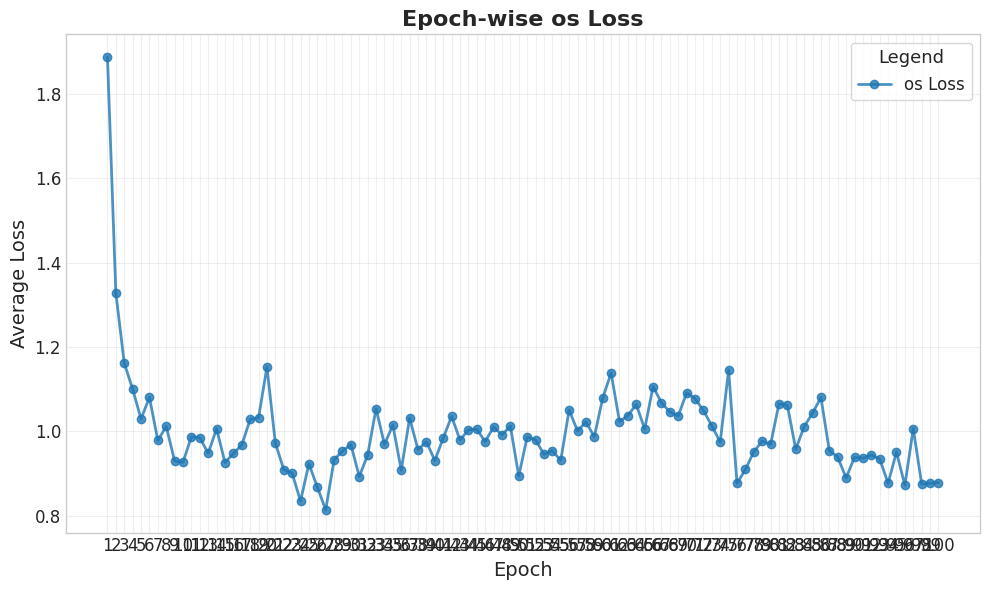

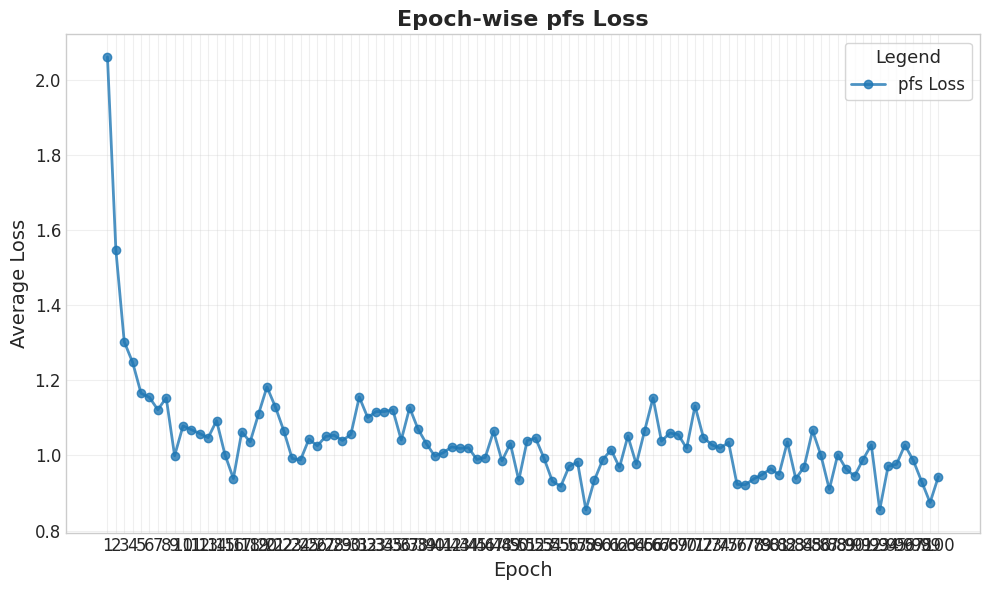

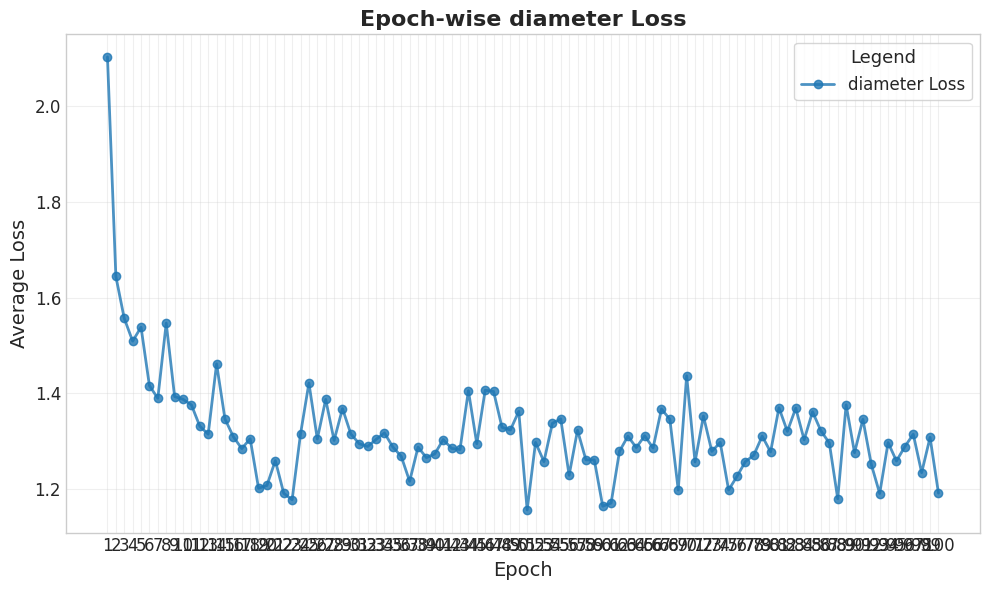

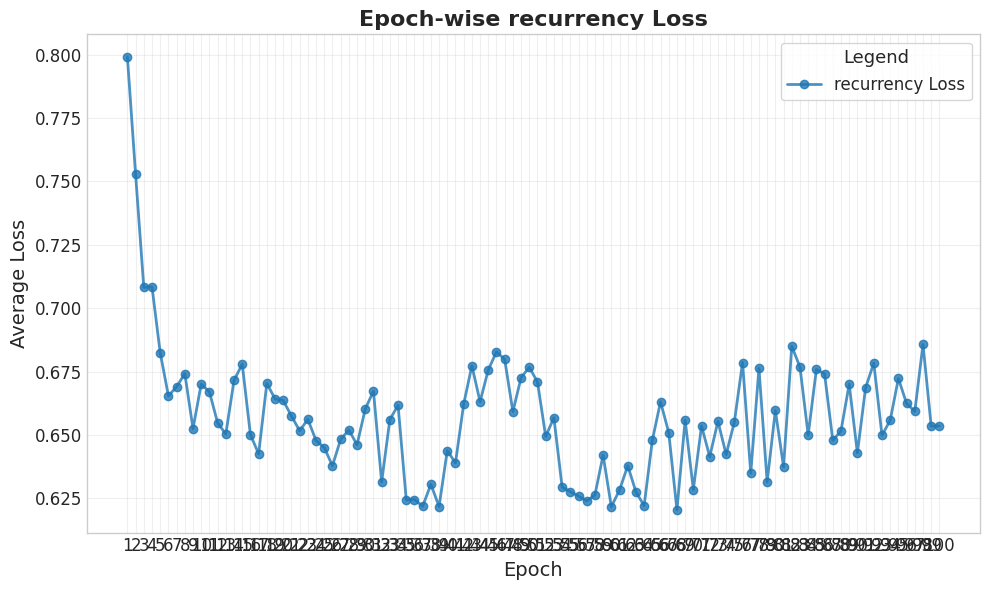

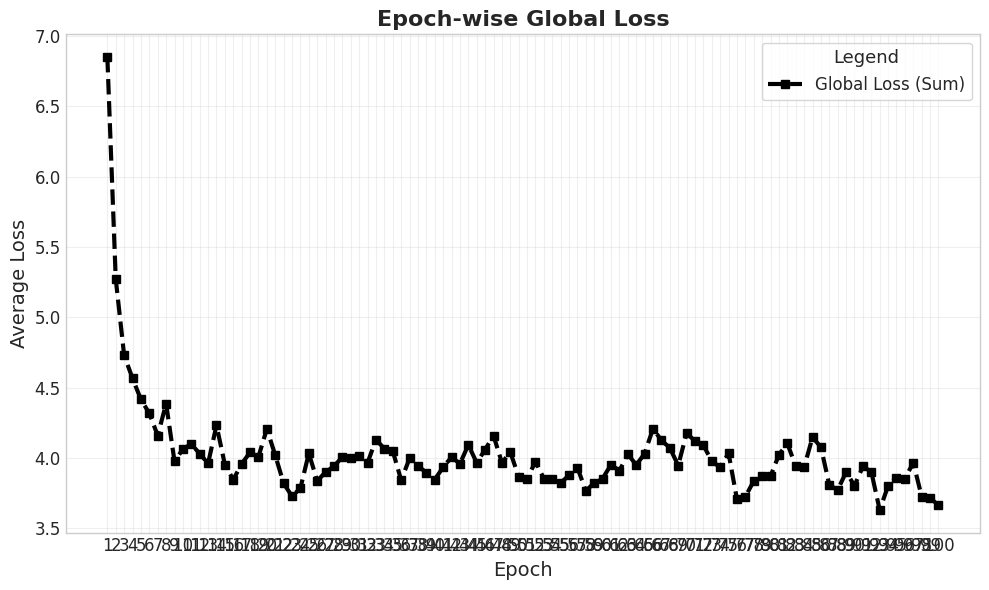

In [31]:
epoch_losses = {key:[] for key in list(predictive_cfg['heads_configs'].keys())}
EPOCHS_II_LOSSES = []
# Save embedding plots
emb_frame_dirs = ['emb_clm']
for d in emb_frame_dirs:
    os.makedirs(d, exist_ok=True)
    
for epoch in range(1, EPOCHS_II+1):
    batch_losses = {key:[] for key in list(predictive_cfg['heads_configs'].keys())}
    overall_losses = []
    for idx, batch in enumerate(dataloader):
        # Get batch
        patient_ids, modalities, X_dict, avail_mods, batch_targets, targets_names = batch
        # print(batch_targets.size())
        # Forward pass
        gbmnet.mme.train()
        contrastive_outputs = gbmnet.mme(X_dict)
        
        clm.train()
        task_outputs, patient_embeddings = clm(contrastive_outputs, avail_mods)
        
        overall_loss = torch.tensor(0, device=device)
        for i, key in enumerate(task_outputs.keys()):
            if key != 'recurrency':
                mse_loss = mse_loss_fn(task_outputs[key].squeeze(), batch_targets[:,i])
                overall_loss = torch.add(overall_loss, mse_loss)
                batch_losses[key].append(mse_loss.item())
            
        bce_loss = bce_loss_fn(task_outputs["recurrency"], batch_targets[:,-2:])
        overall_loss = torch.add(overall_loss, bce_loss)
        batch_losses["recurrency"].append(bce_loss.item())

        overall_loss.backward()
        overall_losses.append(overall_loss.item())
        
        optimizer_II.step()
        scheduler_II.step()
        
    for key in task_outputs.keys():
        epoch_losses[key].append(np.mean(batch_losses[key]))
    EPOCHS_II_LOSSES.append(np.mean(overall_losses))
    print(f"Epoch {epoch} total loss: {EPOCHS_II_LOSSES[-1]:.4f}".upper())
    
    # Inference on all original patient samples
    patient_ids, modalities, X_dict, avail_mods, batch_targets, targets_names = batch_all
    gbmnet.mme.eval()
    contrastive_outputs = gbmnet.mme(X_dict)
    clm.eval()
    _, true_patient_embeddings = clm(contrastive_outputs, avail_mods)
    figs = see_emb(reducer='tsne', patient_embs=true_patient_embeddings)
    for i, fig in enumerate(figs):
        path = os.path.join(emb_frame_dirs[i], f'epoch_{epoch:03d}.png')
        fig.savefig(path, dpi=150, bbox_inches='tight')
        plt.close(fig)
# Prepare data
epochs = list(range(1, len(EPOCHS_II_LOSSES) + 1))
global_loss = EPOCHS_II_LOSSES

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')  # clean, modern grid

# Plot per-modality curves
for task, losses in epoch_losses.items():
    plt.figure(figsize=(10,6))
    plt.plot(epochs, losses, marker='o', linewidth=2, alpha=0.8, label=f'{task} Loss')
    plt.title(f'Epoch-wise {task} Loss', fontsize=16, weight='bold')
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Average Loss', fontsize=14)
    plt.xticks(epochs)
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.legend(title='Legend', fontsize=12, title_fontsize=13, loc='upper right', frameon=True)
    plt.grid(True, which='major', linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot global loss
plt.figure(figsize=(10,6))
plt.plot(epochs, global_loss,
        marker='s', linewidth=3, linestyle='--',
        color='black', label='Global Loss (Sum)')

# Aesthetic tweaks
plt.title('Epoch-wise Global Loss', fontsize=16, weight='bold')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Average Loss', fontsize=14)
plt.xticks(epochs)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(title='Legend', fontsize=12, title_fontsize=13, loc='upper right', frameon=True)
plt.grid(True, which='major', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
make_matplotlib_gif('emb_clm', 'emb_clm_animation.gif', fps=4, max_frames=EPOCHS_II)

Saved animation to emb_clm_animation.gif


/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


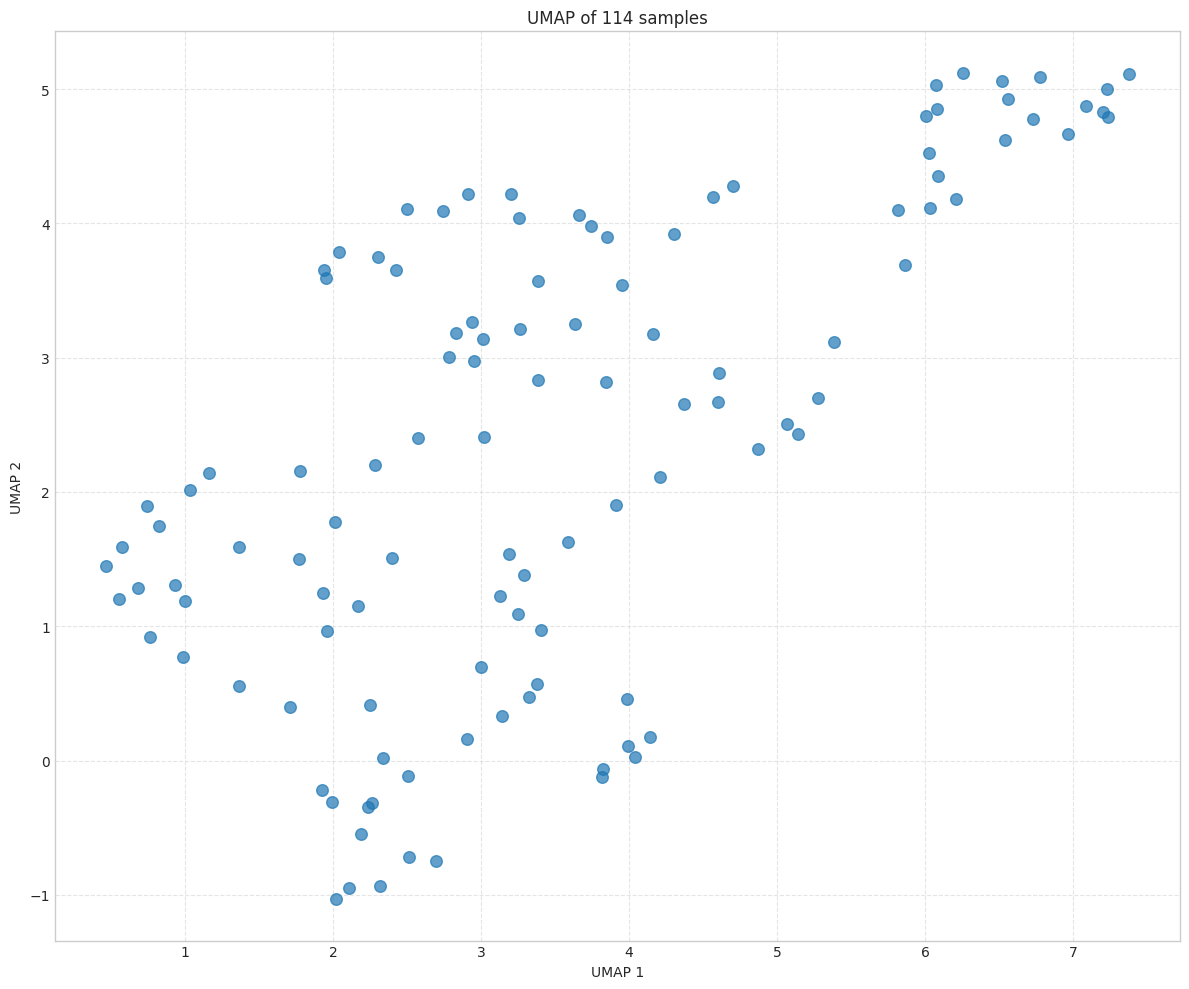

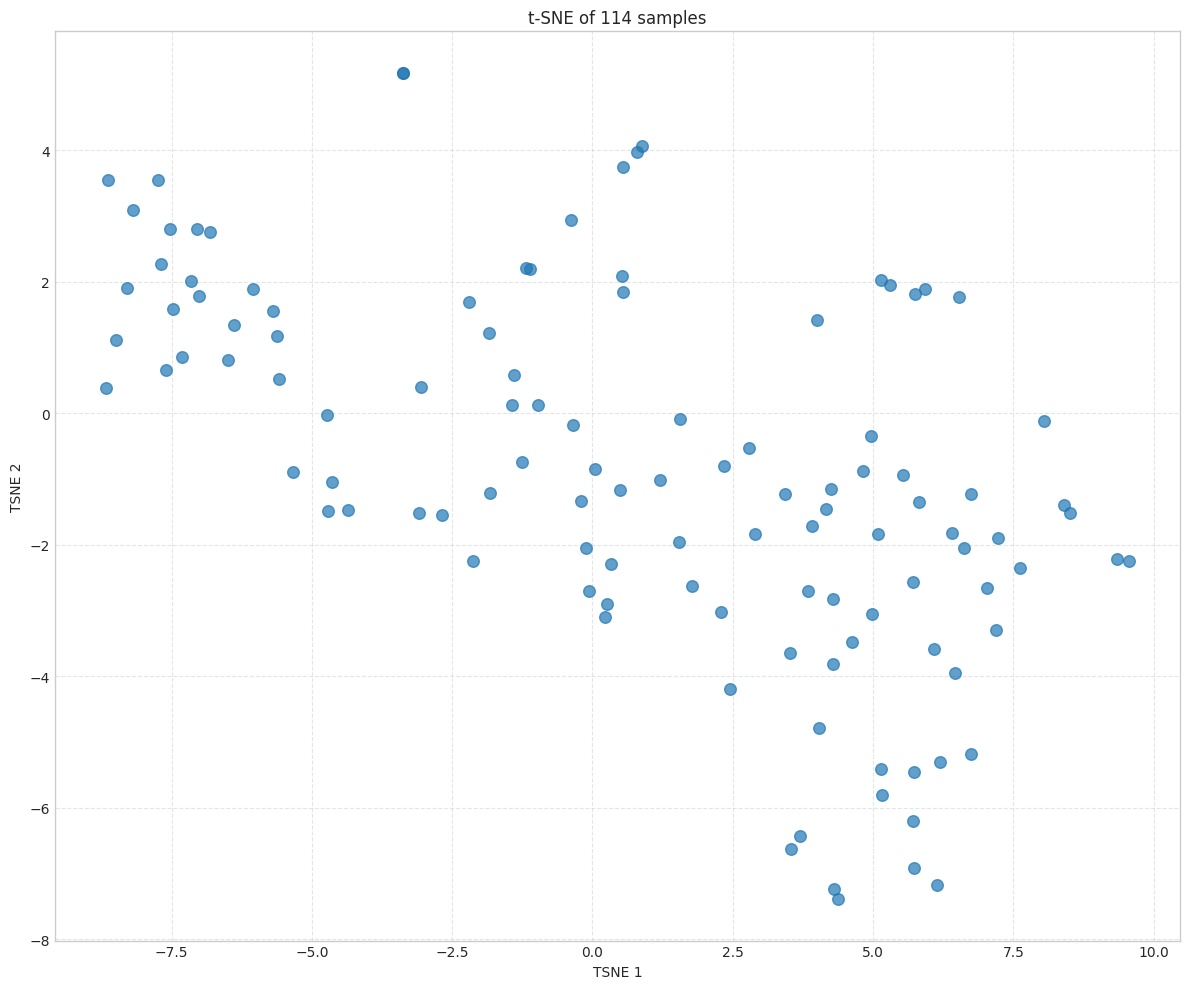

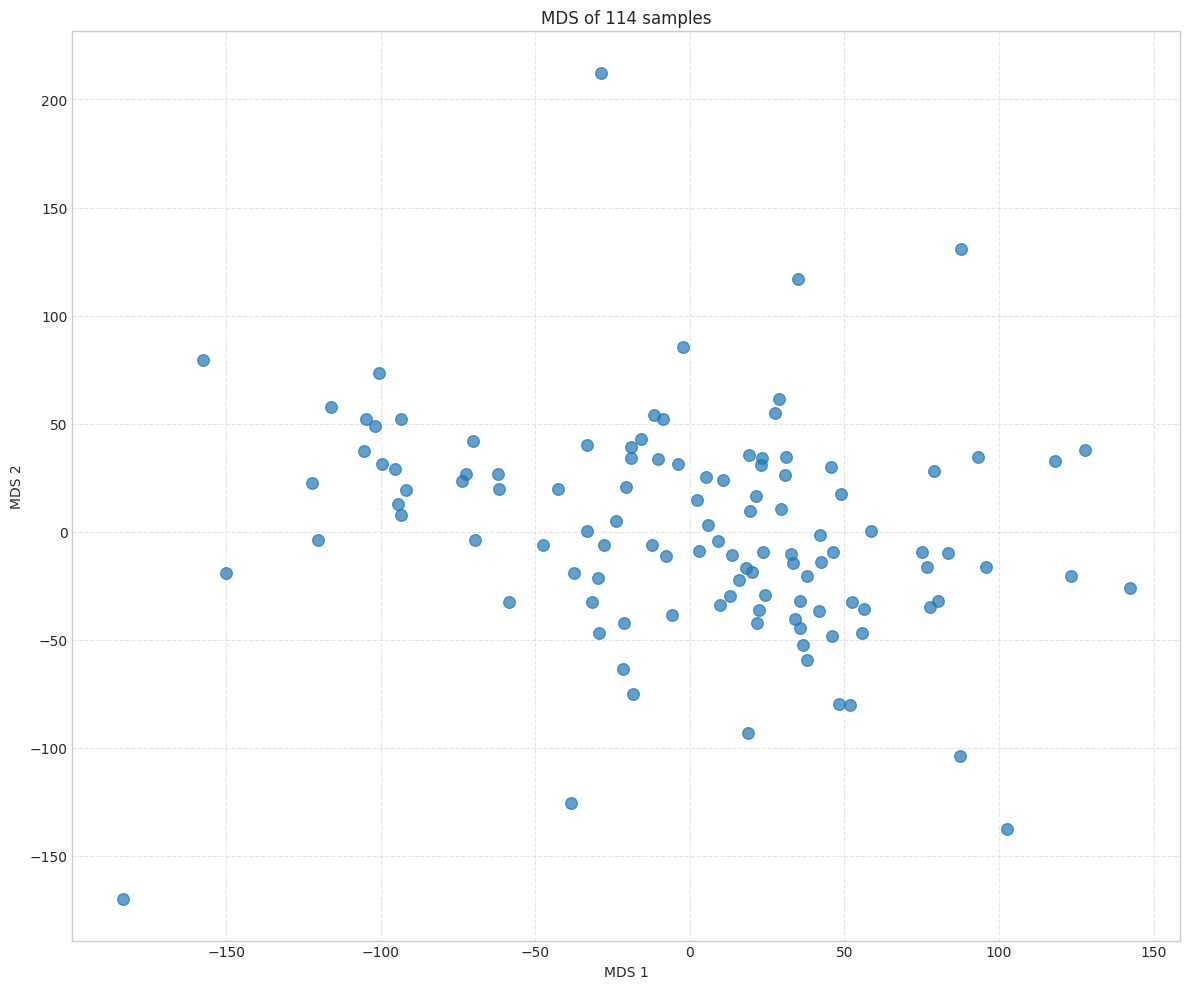

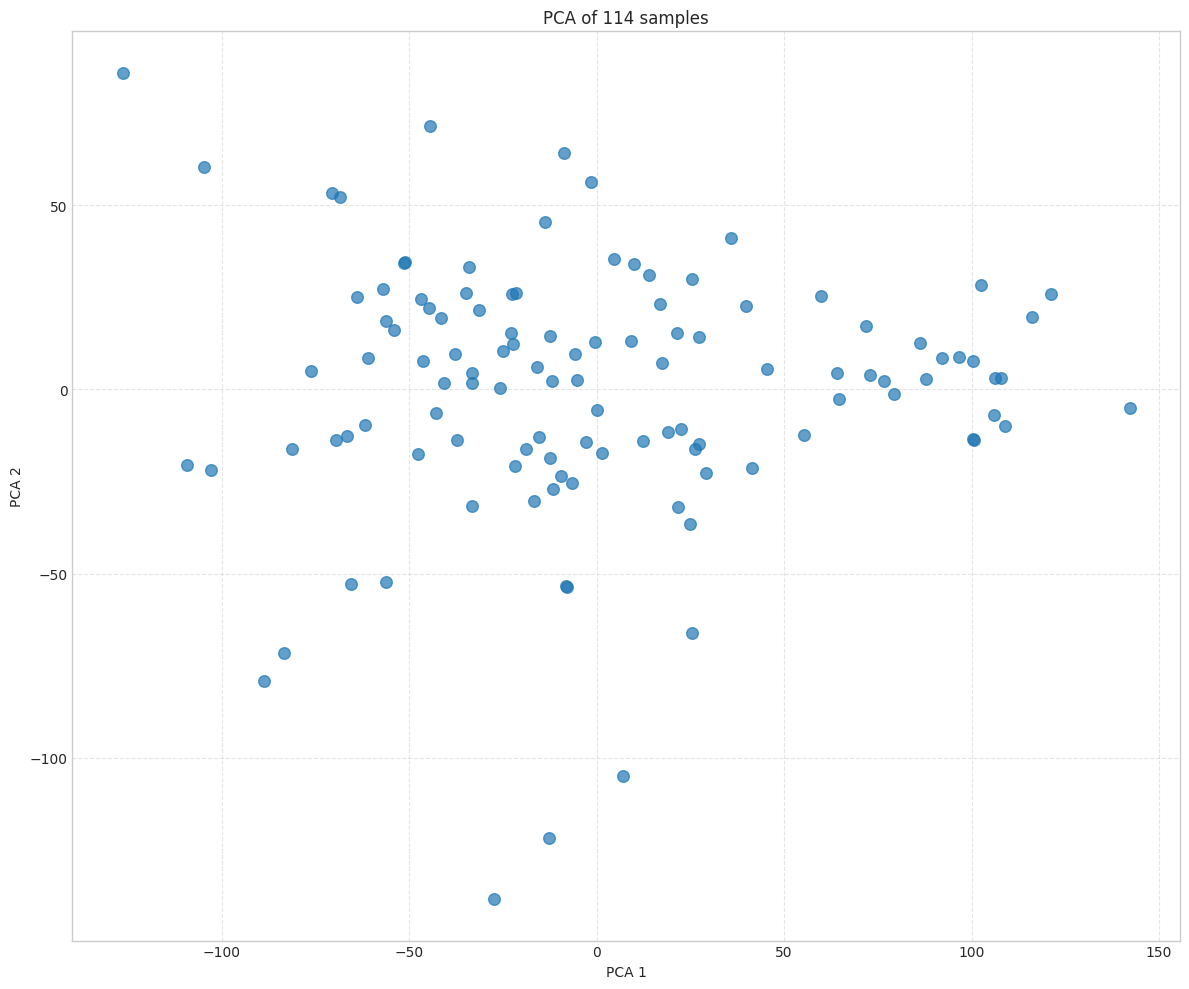

In [33]:
# Inference on all original patient samples
patient_ids, modalities, X_dict, avail_mods, batch_targets, targets_names = batch_all
gbmnet.mme.eval()
contrastive_outputs = gbmnet.mme(X_dict)
clm.eval()
_, true_patient_embeddings = clm(contrastive_outputs, avail_mods)
figs = see_emb(reducer='umap', patient_embs=true_patient_embeddings)
plt.show()
figs = see_emb(reducer='tsne', patient_embs=true_patient_embeddings)
plt.show()
figs = see_emb(reducer='mds', patient_embs=true_patient_embeddings)
plt.show()
figs = see_emb(reducer='pca', patient_embs=true_patient_embeddings)
plt.show()

/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Best Silouhette Score :0.4542422592639923


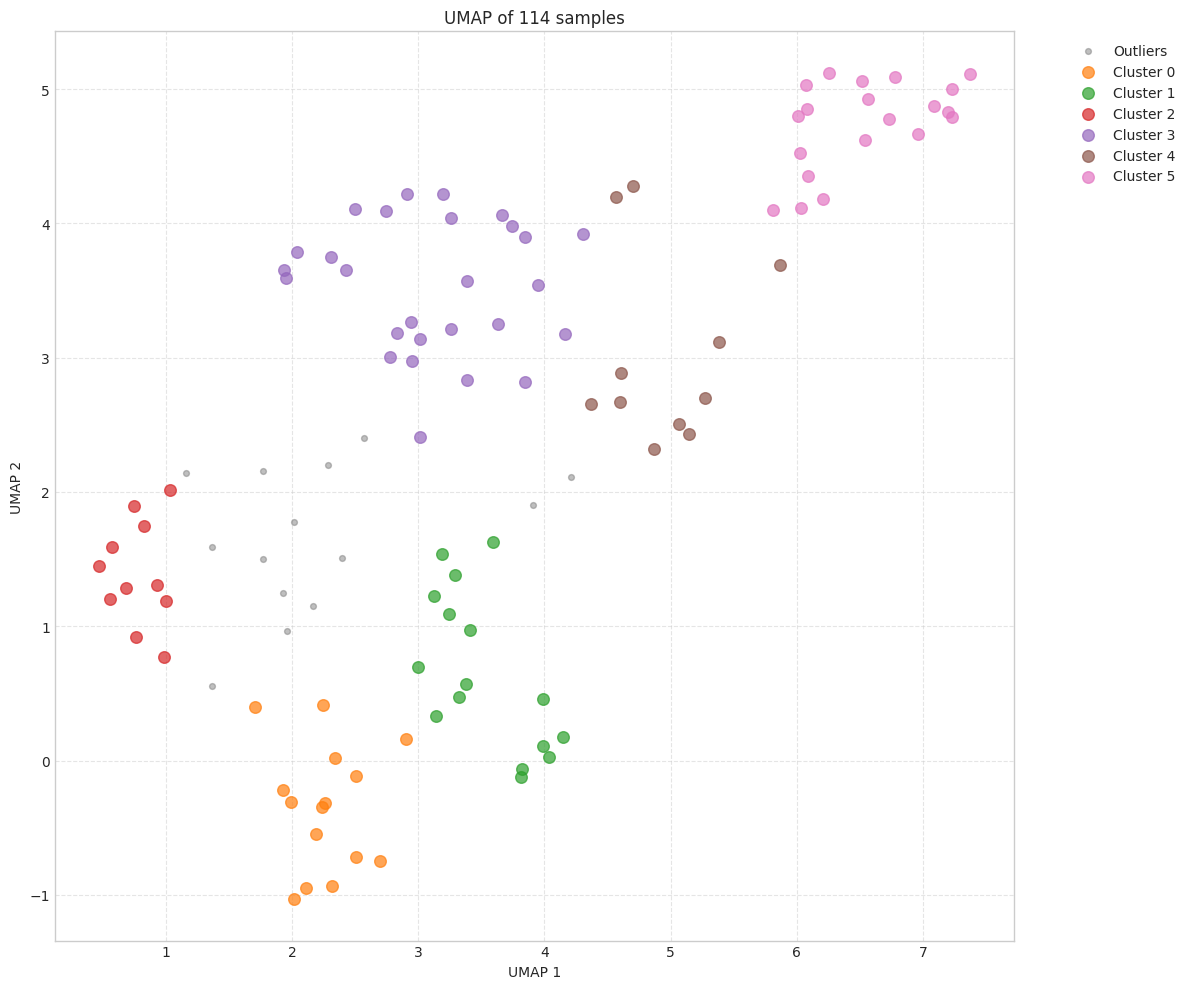

In [57]:
visualize_embeddings(true_patient_embeddings, 'umap', cluster_method='optics', return_fig=True)
plt.show()